# Import

In [1]:
from itertools import product
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy import (stats)
from scipy.stats import norm, lognorm, gaussian_kde
import seaborn as sns
import string
from tqdm import tqdm
import warnings

generate_dontread = False
matplotlib.rcParams['figure.dpi'] = 100
alphabet = string.ascii_lowercase

In [2]:
import sys
sys.path.insert(0, '../src')
sys.path.insert(0, '../../shared')

from funcs_unit_conversion import hi2, hi3, lo2

from customstats import weighted_lognorm_fit, shapiro_wilk_weighted, _royston_pvalue, empirical_metadata, NestedDictValues, weighted_ecdf, estimate_maxima, weighted_kurtosis, weighted_skew, wasserstein1_weighted, wasserstein2_weighted, weighted_mean, weighted_var, weighted_distance_norm, weighted_quantile, weighted_bw, weighted_std

from datageneration import random_samples, generate_random_numbers, random_irregular_dataset, random_logcount

from datavisualization import scale_lightness

from funcs_unit_conversion import dict_unitconv, dict_unittype, consistent_units, str2valunit


In [3]:
rankth = {}

for i in np.arange(1,100):
    if i % 10 == 1:
        rankth[i] = f'{i}st'
    elif i % 10 == 2:
        rankth[i] = f'{i}nd'
    elif i % 10 == 3:
        rankth[i] = f'{i}rd'
    else:
        rankth[i] = f'{i}th'
rankth[11] = '11th'
rankth[12] = '12th'
rankth[13] = '13th'



# Generating data and models

## Functions

In [4]:
# # visualizing range of S for lognormal distribution
# loc=0
# scale=1
# xplot = np.linspace(0,4,1_000)
# S = np.linspace(0.5,1.5,100)
# colors = sns.color_palette('Blues', len(S))

# fig, ax = plt.subplots(figsize=(6,2))
# for s, color in zip(S, colors):
#     if color == colors[0]: color = 'black'
#     yplot = stats.lognorm.pdf(xplot, s, loc, scale)
#     ax.plot(xplot, yplot, color=color)
# ax.text(1,1, f'light is {S[0]}, dark is {S[-1]}', ha='right', va='top', transform=ax.transAxes)

In [5]:
# # visualizing range of df for t distribution
# xplot = np.linspace(-5,5,1_000)
# loc = 0
# scale = 2
# DF = np.linspace(2,8,100)
# colors = sns.color_palette('Blues', len(DF))



# fig, ax = plt.subplots(figsize=(6,2))
# for df, color in zip(DF, colors):
#     if color == colors[0]: color = 'black'
#     yplot = stats.t.pdf(xplot, df, loc, scale)
#     ax.plot(xplot, yplot, color=color)
# ax.text(1,1, f'light is {DF[0]}, dark is {DF[-1]}', ha='right', va='top', transform=ax.transAxes)

In [6]:
# # visualizing range of a for skewnorm distribution
# xplot = np.linspace(-5,10,1_000)
# loc = 0
# scale = 1
# A = np.linspace(-1,6,100)
# colors = sns.color_palette('Blues', len(A))



# fig, ax = plt.subplots(figsize=(6,2))
# for a, color in zip(A, colors):
#     if color == colors[0]: color = 'black'
#     yplot = stats.skewnorm.pdf(xplot, a, loc, scale)
#     ax.plot(xplot, yplot, color=color)
# ax.text(1,1, f'light is {A[0]}, dark is {A[-1]}', ha='right', va='top', transform=ax.transAxes)

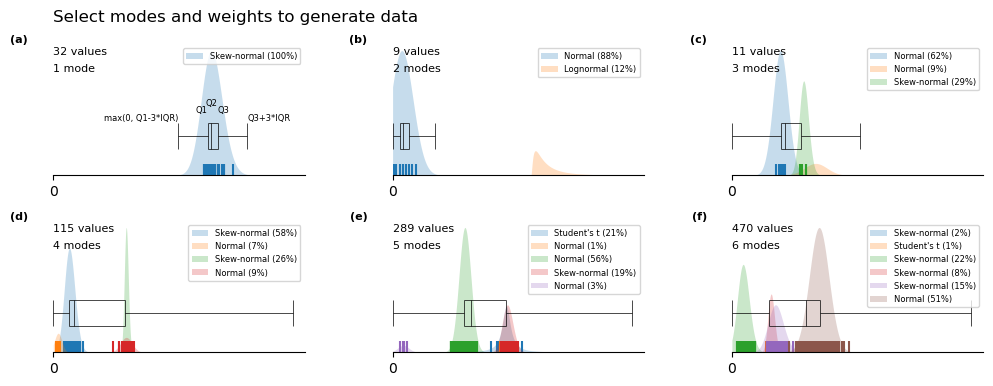

In [7]:
# plot demonstrating what random number generation looks like in this study
ncols = 3
nrows = 2
xplot = np.linspace(0,30,1_000)
np.random.seed(42)
fig, axes = plt.subplots(nrows, ncols, figsize=(12,4), gridspec_kw=dict(hspace=0.35, wspace=0.35))

row, col = (0,0)
for i in range(ncols*nrows):
    ax = axes[row, col]

    # prepare inputs
    nmodes = i+1
    nvals = int(random_logcount(lo=4, hi=1000, n=1)[0])
    locs = np.random.uniform(0,20,nmodes)
    scales = np.random.uniform(0.5,2.0,nmodes)
    types = np.random.choice(['gauss', 'skewnorm', 'studentt', 'lognorm'], size=nmodes, p=[0.40, 0.25, 0.25, 0.10])
    weights = np.random.dirichlet(np.ones(nmodes))
    counts = np.random.multinomial(nvals, weights)
    colors = sns.color_palette('tab10', nmodes)

    # plot
    data = []
    for loc, scale, type, weight, count, color in zip(locs, scales, types, weights, counts, colors):
        if type == 'gauss':
            label = 'Normal'
            yplot = stats.norm.pdf(xplot, loc, scale)

        elif type == 'skewnorm':
            label = 'Skew-normal'
            a = 1
            yplot = stats.skewnorm.pdf(xplot, a, loc, scale)

        elif type == 'studentt':
            label = "Student's t"
            df = 1
            yplot = stats.t.pdf(xplot, df, loc, scale)

        elif type == 'lognorm':
            label = 'Lognormal'
            s = 1
            yplot = stats.lognorm.pdf(xplot, s, loc, scale)
        
        label = f"{label} ({int(np.round(weight*100,0))}%)"
        ax.fill_between(xplot, yplot*weight, label=label, alpha=0.25, color=color, linewidth=0)

        vals = generate_random_numbers(type, loc, scale, count)
        data += list(vals)
        ax.scatter(vals, [0]*len(vals), marker='|', s=250, color=color)


    # add box plot

    # format
    ax.legend(fontsize=6)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_ylim(0,)
    ax.set_xlim(0,)
    ax.set_xticks([0.])
    ax.text(0, 0.98, f'{nvals} values', ha='left', va='top', transform=ax.transAxes, fontsize=8)
    if nmodes == 1:
        text = f'{nmodes} mode'
    else:
        text = f'{nmodes} modes'
    ax.text(0, 0.85, text, ha='left', va='top', transform=ax.transAxes, fontsize=8)
    ax.text(-0.1, 1.0, f'({alphabet[i]})', ha='right', va='bottom', transform=ax.transAxes, fontsize=8, weight='bold')


    # add boxplot
    q1, q2, q3 = np.quantile(data, [0.25, 0.5, 0.75])
    iqr = q3-q1
    xhi = q3 + 3*iqr
    xlo = np.max([q1-3*iqr, 0])

    ymin, ymax = ax.get_ylim()
    ylo = ymin + (ymax-ymin)*0.2
    yhi = ymin + (ymax-ymin)*0.4

    color = 'black'
    lw = 0.5
    ax.vlines([xlo, q1, q2, q3, xhi], ylo, yhi, color=color, linewidth=lw)
    ax.hlines([ylo, yhi], q1, q3, color=color, linewidth=lw)
    ax.hlines(np.mean([ylo, yhi]), xlo, q1, color=color, linewidth=lw)
    ax.hlines(np.mean([ylo, yhi]), xhi, q3, color=color, linewidth=lw)

    if (row, col) == (0,0):
        ax.text(0, 1.15, 'Select modes and weights to generate data', ha='left', va='bottom', transform=ax.transAxes, fontsize=12)
        ax.text(xlo, yhi, 'max(0, Q1-3*IQR)', ha='right', va='bottom', fontsize=6)
        ax.text(q1, yhi*1.15, 'Q1', ha='right', va='bottom', fontsize=6)
        ax.text(q2, yhi*1.30, 'Q2', ha='center', va='bottom', fontsize=6)
        ax.text(q3, yhi*1.15, 'Q3', ha='left', va='bottom', fontsize=6)
        ax.text(xhi, yhi, 'Q3+3*IQR', ha='left', va='bottom', fontsize=6)

    xmin, xmax = ax.get_xlim()
    if xmax < xhi:
        ax.set_xlim(0, xhi*1.05)

    if col == ncols-1:
        col = 0
        row += 1
    else:
        col += 1

plt.savefig('../outputs/figures/CompareUQMethods_FIG_DemonstrateDataGeneration.png', bbox_inches='tight', dpi=1200)

## Pull empirical data from EC3

In [8]:
# pull real ECCs

if generate_dontread == True:

    # pull EPDs from EC3 to get metrics from those data as well
    filepath = '../../EPDsFromEC3/EPD_AllOfEC3'
    filenames = [ele for ele in os.listdir(filepath) if ele.startswith('EPDs')]
    dct_realeccs = {}

    filenames_error = []
    for filename in tqdm(filenames, total=len(filenames)):
        try: 
            mat = filename.split('_')[1]
            dft = pd.read_csv(f'{filepath}/{filename}', dtype=str)[['gwp', 'declared_unit']]
            unitvals, unit, unaccounted_units = consistent_units(dft['declared_unit'])
            dft['declared_unit'] = unitvals
            dft['gwp'] = np.array(dft['gwp'].apply(str2valunit).tolist())[:,0]
            dft = dft.dropna()
            dft = dft.loc[dft['gwp'] != 'nan']
            dft = dft.astype(float)
            dft['gwp'] = dft['gwp']/dft['declared_unit']
            dft = dft.loc[dft['gwp'] > 0]
            if len(dft) > 1:
                dct_realeccs[mat] = dft['gwp'].values
        except:
            filenames_error.append(filename)
            

    # get rid of extreme outliers in all datasets
    dct_realeccs_trimmed = {}
    for mat in dct_realeccs:
        data = dct_realeccs[mat]
        q1, q3 = np.quantile(data, [0.25, 0.75])
        iqr = q3-q1
        data = data[data<q3+3*iqr]
        data = data[data>q1-3*iqr]
        if len(data) < 3:
            continue
        dct_realeccs_trimmed[mat] = {'data': None, 'weights': None}
        dct_realeccs_trimmed[mat]['data'] = data
        dct_realeccs_trimmed[mat]['weights'] = np.random.dirichlet(np.ones_like(data)*5)

    # write dct_realeccs_trimmed to json file
    # Create a JSON Encoder class
    class json_serialize(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer):
                return int(obj)
            if isinstance(obj, np.floating):
                return float(obj)
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            return json.JSONEncoder.default(self, obj)

    with open('../data/processed/dct_realeccs_trimmed.json', 'w') as file:
        json.dump(dct_realeccs_trimmed, file, cls=json_serialize)

# otherwise, just pull from file
else:

    with open('../data/processed/dct_realeccs_trimmed.json', 'r') as file:
        dct_realeccs_trimmed = json.load(file)

    for mat in dct_realeccs_trimmed:
        dct_realeccs_trimmed[mat]['data'] = np.array(dct_realeccs_trimmed[mat]['data'])
        dct_realeccs_trimmed[mat]['weights'] = np.array(dct_realeccs_trimmed[mat]['weights'])


# interpret metrics for all real datasets
dct_realeccmetrics = {}
mat2del = []
for mat in dct_realeccs_trimmed:
    data = dct_realeccs_trimmed[mat]['data']
    weights = dct_realeccs_trimmed[mat]['weights']
    data = data/np.mean(data)
    try:
        dct_realeccmetrics[mat] = empirical_metadata(data, weights)
    except:
        continue


df_realeccmetrics = pd.DataFrame(dct_realeccmetrics).T
df_realeccmetrics.to_excel('../outputs/tables/TABLE_EmpiricalECCMetrics.xlsx')


/Users/martintorres/Dropbox/Work/CUBoulder/Dissertation/Coding/CompareUQMethods/notebooks/../src/customstats.py:401: RuntimeWarning: divide by zero encountered in scalar divide
  g2 = n**2*((n+1)*m4-3*(n-1)*m2**2)/((n-1)*(n-2)*(n-3)) * (n-1)**2/(n**2*m2**2)
/Users/martintorres/Dropbox/Work/CUBoulder/Dissertation/Coding/CompareUQMethods/notebooks/../src/customstats.py:401: RuntimeWarning: invalid value encountered in scalar divide
  g2 = n**2*((n+1)*m4-3*(n-1)*m2**2)/((n-1)*(n-2)*(n-3)) * (n-1)**2/(n**2*m2**2)
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 77548.
  res = hypotest_fun_out(*samples, **kwds)
/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8925.
  res =

## Generate data or read data from file

In [9]:
# # sample and visualize a single dataset

# data, weights = random_irregular_dataset(
#     n=100,
# )
# meta = empirical_metadata(data, weights)

# print(meta)

# fig, ax = plt.subplots(figsize=(6,2))
# dft = pd.DataFrame({'data':data, 'weights':  weights})
# sns.kdeplot(dft, x='data', weights='weights', ax=ax, label='weighted')
# sns.kdeplot(dft['data'], ax=ax, label='unweighted')
# ax.scatter(data, [0]*len(data), marker='|', s=weights/np.max(weights)*500, color='black', zorder=3)
# ax.legend()
# ax.spines[['top', 'right', 'left']].set_visible(False)
# ax.get_yaxis().set_visible(False)
# ax.set_xlabel('')

In [10]:
# generate datasets, takes ~6 minutes for 15k

if generate_dontread == True:

    ndatasets = 15_000
    DATA_all = {f'dataset{i}': {} for i in range(ndatasets)}

    for i in tqdm(range(ndatasets), total=ndatasets):
        dataset = f'dataset{i}'
        
        n = int(random_logcount(lo=4, hi=1000, n=1)[0])
        data, weights = random_irregular_dataset(n=n)
        metrics = empirical_metadata(data, weights)
        
        DATA_all[dataset]['data'] = data
        DATA_all[dataset]['weights'] = weights
        DATA_all[dataset]['metrics'] = metrics

    # save DATA_all as json

    # Create a JSON Encoder class
    class json_serialize(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer):
                return int(obj)
            if isinstance(obj, np.floating):
                return float(obj)
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            return json.JSONEncoder.default(self, obj)

    with open('../data/processed/DATA_all.json', 'w') as file:
        json.dump(DATA_all, file, cls=json_serialize)


# otherwise, read DATA_all from file
else:
    with open('../data/processed/DATA_all.json', 'r') as file:
        DATA_all = json.load(file)

    # convert lists to arrays
    for dataset in DATA_all:
        DATA_all[dataset]['data'] = np.array(DATA_all[dataset]['data'])
        DATA_all[dataset]['weights'] = np.array(DATA_all[dataset]['weights'])


In [11]:
# put all metrics into a single dataframe
dataset = list(DATA_all.keys())[0]
df_metrics_alldata = pd.DataFrame(columns=DATA_all[dataset]['metrics'].keys())
for dataset in tqdm(DATA_all, total=len(DATA_all)):
    df_metrics_alldata.loc[dataset] = DATA_all[dataset]['metrics']

100%|██████████| 15000/15000 [00:50<00:00, 297.76it/s]


In [12]:
# get rid of the datasets with outlier metrics, as defined by IQR +/- 1.5 IQR
datasets_outliers = []
for metric in df_metrics_alldata.columns:
    srs = df_metrics_alldata[metric]
    q1, q2, q3 = np.quantile(srs, [0.25, 0.5, 0.75])
    std = np.std(srs)
    iqr = np.max([q3-q1, std*1.35])
    cutoff_hi = q3+1.5*iqr
    cutoff_lo = q1-1.5*iqr
    for ind in list(srs.loc[srs>cutoff_hi].index) + list(srs.loc[srs<cutoff_lo].index):
        if ind not in datasets_outliers:
            datasets_outliers.append(ind)

            
datasets_outliers = list(set(datasets_outliers))
# for dataset in datasets_outliers:
#     if dataset in DATA_all:
#         del DATA_all[dataset]


In [13]:
print(f'Size of DATA_all went from {len(DATA_all)} to {len(DATA_all)-len(datasets_outliers)}. Removed {np.round(1-(len(DATA_all)-len(datasets_outliers))/len(DATA_all),3)*100}%')

Size of DATA_all went from 15000 to 10869. Removed 27.500000000000004%


In [14]:
# get a list of which datasets should be trimmed to get to 10k and write to file
datasets = list(DATA_all.keys())
datasets_trimto10k = [ele for ele in datasets if ele not in datasets_outliers][10_000:]
datasets_trimmed = [ele for ele in datasets if ele not in datasets_trimto10k and ele not in datasets_outliers]

# write to file
lsts = [datasets_outliers, datasets_trimto10k]
labels = ['datasets_outliers', 'datasets_trimto10k']
for lst, label in zip(lsts, labels):
    with open(f"../data/processed/{label}.json", "w") as f:
        json.dump(lst, f)

# # read from file
# with open('../data/processed/datasets_outliers.json', 'r') as f:
#     datasets_outliers = json.load(f)

# with open('../data/processed/datasets_trimto10k.json', 'r') as f:
#     datasets_trimto10k = json.load(f)



In [15]:
# # trim down to 10_000 datasets
DATA = {key: DATA_all[key] for key in datasets_trimmed}

# pare down metrics to remaining datasets
df_metrics = df_metrics_alldata.loc[DATA.keys()].copy()

In [16]:
# generate new combos
nmats = 4
if generate_dontread == True:
    combos = np.array(list(DATA.keys()))
    np.random.shuffle(combos)
    # combos = combos[:1000]
    combos = combos[:int(np.floor(len(combos)/nmats))*nmats]
    combos = combos.reshape(int(len(combos)/nmats), nmats)

    # write in combos
    with open('../data/processed/combos.txt', 'w') as file:
        file.write(str(list(combos.flatten())))

## Visualize statistical metrics of randomly generated datasets

In [17]:
# read in dictionary with labels for each metric
with open('../src/dct_metriclabels.json', 'r') as file:
    dct_metriclabels = json.load(file)


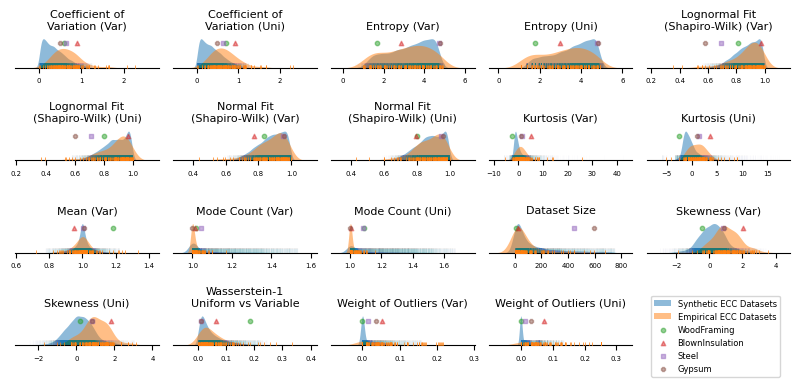

In [71]:
# visualize remaining metrics
stat_metrics = list(DATA[list(DATA.keys())[0]]['metrics'].keys())
stat_metrics.sort()
# results = {k:[] for k in stat_metrics}
# for metric in stat_metrics:
#     for dataset in DATA:
#         results[metric].append(DATA[dataset]['metrics'][metric])

    
ncols = 5
nrows = int(np.ceil(len(stat_metrics)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10,nrows), gridspec_kw=dict(hspace=2.0, wspace=0.1))
(row, col) = (0,0)
ax2del = list(product(range(nrows),range(ncols)))

for metric in stat_metrics:
    if metric == 'mean_uw': continue
    ax = axes[row, col]
    ax2del.remove((row, col))
    
    data_simulated = df_metrics[metric]
    data_empirical = df_realeccmetrics[metric]
    
    if metric == 'n':
        data_empirical = data_empirical[data_empirical<1_000]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
    # sns.stripplot(df_metrics[metric], orient='h', ax=ax, s=1)
        sns.kdeplot(data_simulated, ax=ax, fill=True, linewidth=0, alpha=0.5, color='tab:blue', label='Synthetic ECC Datasets')
        sns.kdeplot(data_empirical, ax=ax, fill=True, linewidth=0, alpha=0.5, color='tab:orange', label='Empirical ECC Datasets')
    ax.scatter(data_simulated, [0]*len(data_simulated), marker='|', color='tab:blue', s=50, linewidth=0.5, alpha=0.01)
    ax.scatter(data_empirical, [0]*len(data_empirical), marker='|', color='tab:orange', s=25, linewidth=0.5, alpha=1.0, zorder=3)
    ax.set_title(dct_metriclabels[metric], fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=5)

    # add material labels
    colors = sns.color_palette('tab10',6)[-4:]
    ymin, ymax = ax.get_ylim()
    for mat, marker, color in zip(['WoodFraming', 'BlownInsulation', 'Steel', 'Gypsum'], ['o', '^', 's', 'P'], colors):
        xloc = df_realeccmetrics.loc[mat,metric]
        yloc = ymin + 0.8*(ymax-ymin)

        ax.scatter(xloc, yloc, marker=marker, color=color, s=10, label=mat, alpha=0.5)

    #format
    ax.set_xlabel('')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.get_yaxis().set_visible(False)
    # move to next axes
    if col < ncols-1:
        col += 1
    else:
        col = 0
        row += 1

for row, col in ax2del:
    fig.delaxes(axes[row, col])

ax = axes[3,3]
ax.legend(bbox_to_anchor=(1.1,1.75), loc='upper left', fontsize=6)

    
plt.savefig('../outputs/figures/CompareUQMethods_SUPP_GeneratedVsEmpiricalMetrics.png', bbox_inches='tight', dpi=1200)

In [19]:
# # visualizing iqr +/- 1.5*iqr
# ncols = 4
# nrows = int(np.ceil(len(results)/ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(6,10), gridspec_kw=dict(hspace=1.0))

# row, col = (0,0)
# i = -1
# for row, col in product(range(nrows), range(ncols)):
#     i += 1
#     metric = list(results.keys())[i]
#     ax = axes[row, col]
#     data = results[metric]
#     with warnings.catch_warnings():
#         warnings.simplefilter('ignore')
#         sns.stripplot(data, orient='h', ax=ax, s=1)
#     q1, q3 = np.quantile(data, [0.25, 0.75])
#     iqr = q3-q1
#     ymin, ymax = ax.get_ylim()
#     ax.vlines(q1-1.5*iqr, ymin, ymax, color='black', zorder=3)
#     ax.vlines(q3+1.5*iqr, ymin, ymax, color='black', zorder=3)
#     ax.set_title(metric)
